<a href="https://colab.research.google.com/github/zakari90/-DataAnalysis/blob/main/bank_marketing_campaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = "/content/drive/MyDrive/hsoub ai/Bank_Marketing_Campaign.csv"
df = pd.read_csv(path)
df.head()

,id,customer_age,job_type,marital,education,default,balance,housing_loan,personal_loan,communication_type,day_of_month,month,last_contact_duration,num_contacts_in_campaign,days_since_prev_campaign_contact,num_contacts_prev_campaign,prev_campaign_outcome,term_deposit_subscribed
0,id_43823,28.0,management,single,tertiary,no,285.0,yes,no,unknown,26,jun,303.0,4.0,NaN,0,unknown,0
1,id_32289,34.0,blue-collar,married,secondary,no,934.0,no,yes,cellular,18,nov,143.0,2.0,132.0,1,other,0
2,id_10523,46.0,technician,married,secondary,no,656.0,no,no,cellular,5,feb,101.0,4.0,NaN,0,unknown,0
3,id_43951,34.0,services,single,secondary,no,2.0,yes,no,unknown,20,may,127.0,3.0,NaN,0,unknown,0
4,id_40992,41.0,blue-collar,married,primary,no,1352.0,yes,no,cellular,13,may,49.0,2.0,NaN,0,unknown,0


In [3]:
null_value_percentage = (df.isnull().sum()/df.shape[0])*100
null_value_percentage.sort_values(ascending = False)

,0
days_since_prev_campaign_contact,81.622271
customer_age,1.955952
balance,1.260783
last_contact_duration,0.982716
marital,0.473979
personal_loan,0.470819
num_contacts_in_campaign,0.353904
id,0.000000
default,0.000000
job_type,0.000000


In [4]:
df.shape

(31647, 18)

In [5]:
df.nunique()

,0
id,31647
customer_age,77
job_type,12
marital,3
education,4
default,2
balance,6563
housing_loan,2
personal_loan,2
communication_type,3


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
cat_cols = [df.columns[i]
            for i in range(1,df.shape[1]-1)
            # select all rows and select the column at integer position i
            if df.iloc[:,i].dtype=='O']
cat_cols
print(list(enumerate(cat_cols)))

[(0, 'job_type'), (1, 'marital'), (2, 'education'), (3, 'default'), (4, 'housing_loan'), (5, 'personal_loan'), (6, 'communication_type'), (7, 'month'), (8, 'prev_campaign_outcome')]


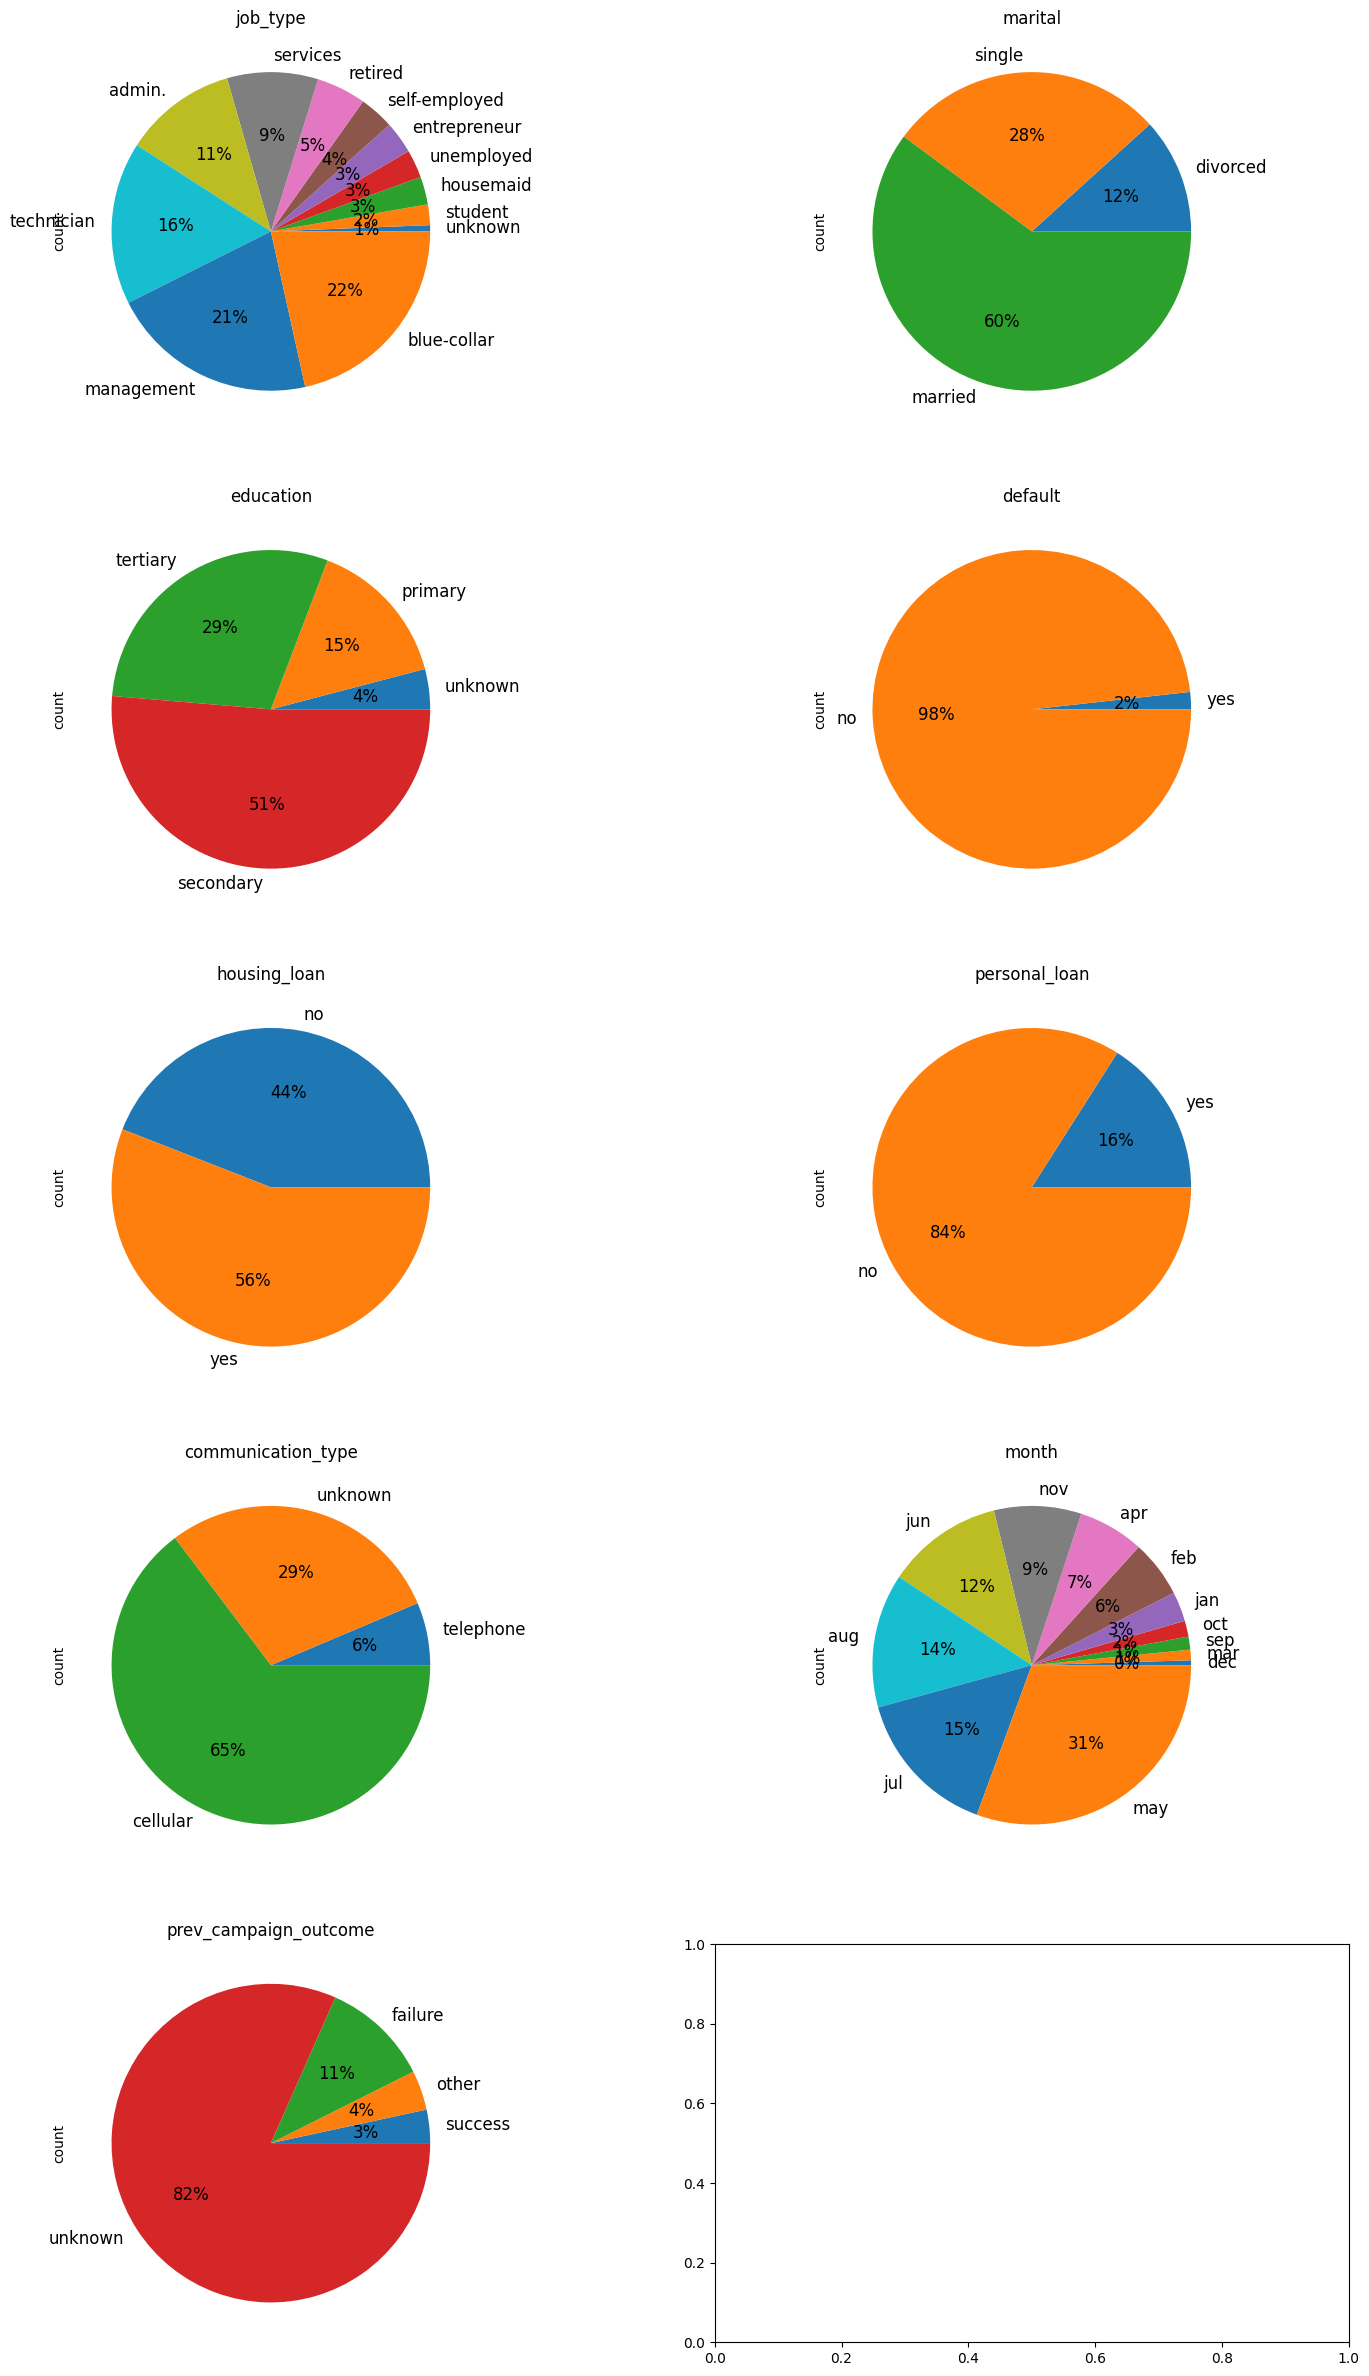

In [8]:
fig, axes = plt.subplots(5, 2, figsize=(18, 30))
axes = [ax for axes_rows in axes for ax in axes_rows]
# for axes_rows in axes:
#     for ax in axes_rows:
#         axes.append(ax)
for i, column in enumerate(df[cat_cols]):
    df[column].value_counts()[::-1].plot(kind='pie', ax=axes[i], title=column, autopct='%.0f%%', fontsize=12)

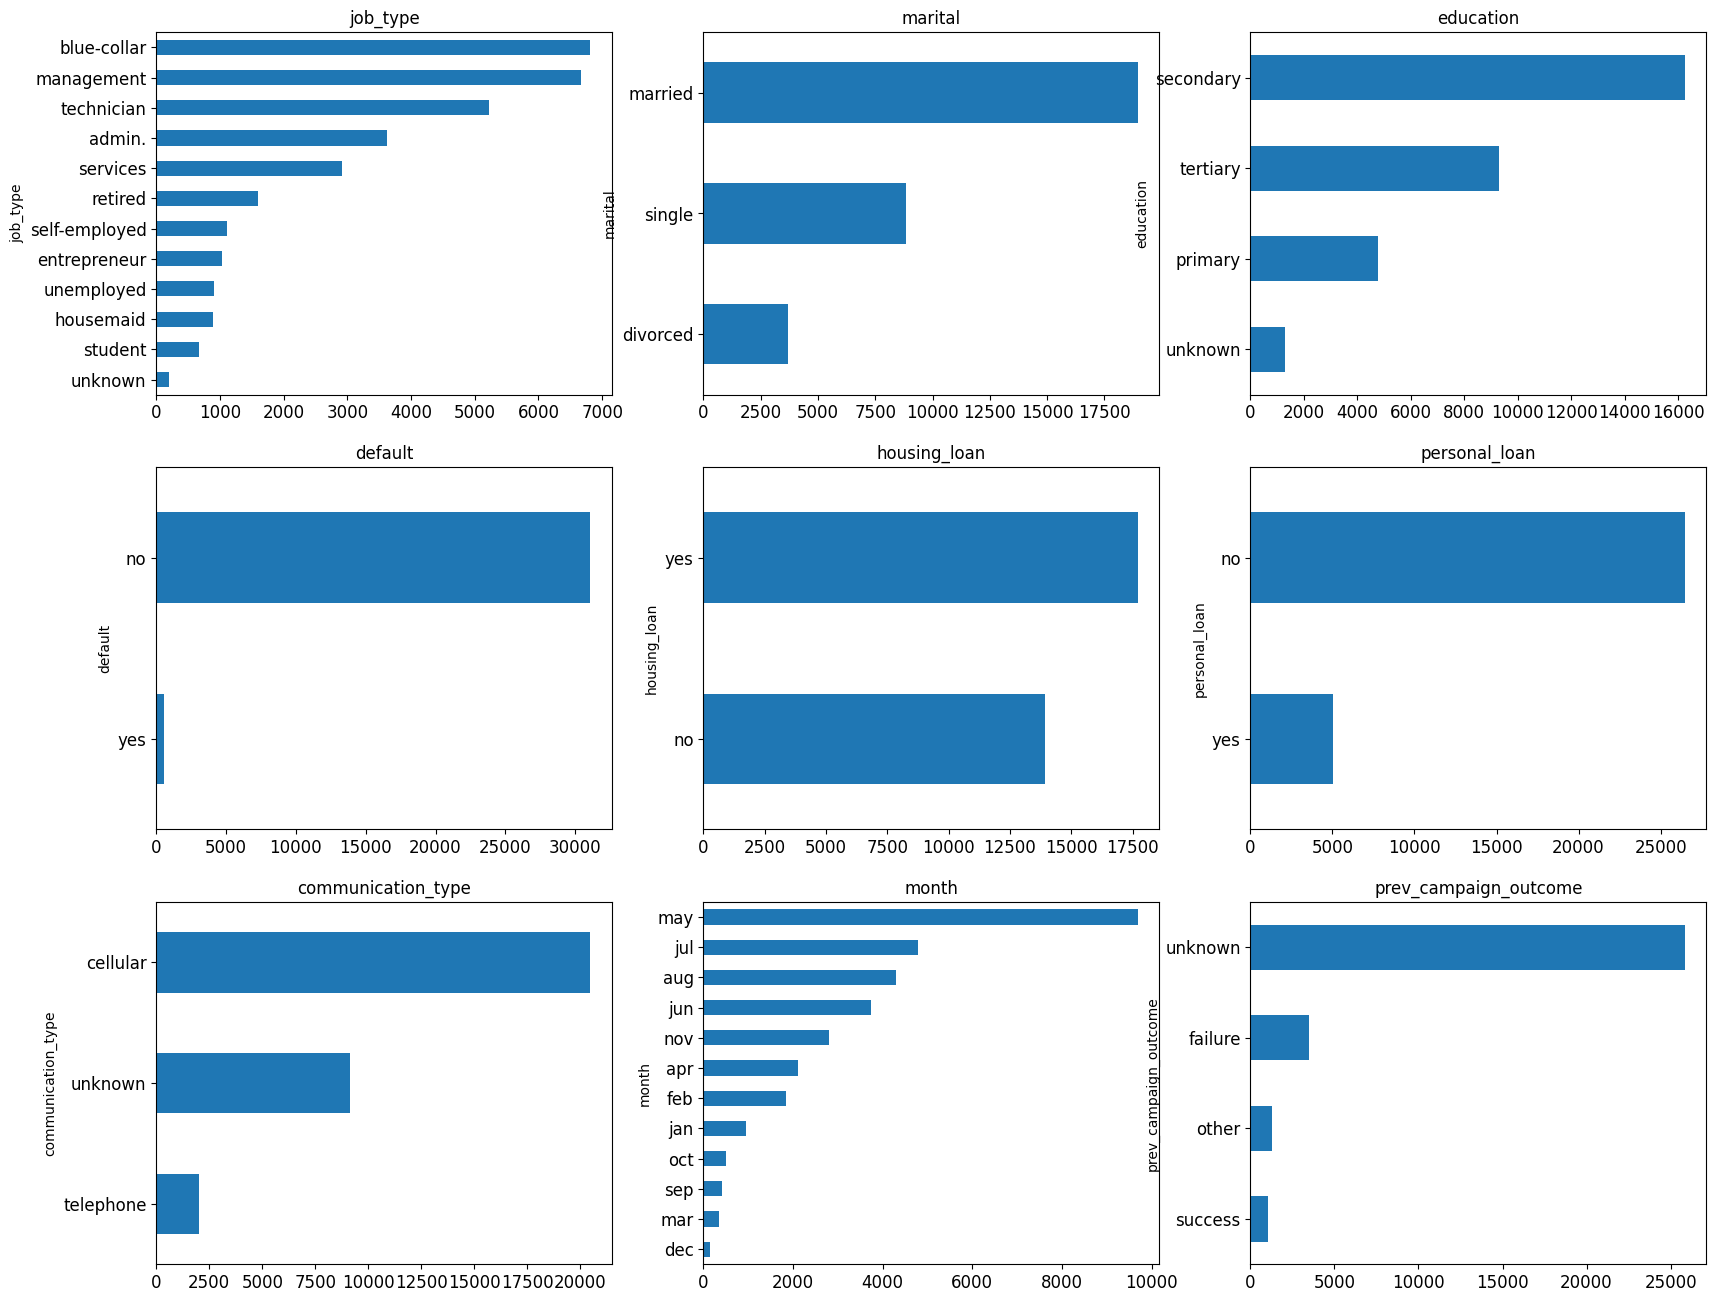

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(20,16))

axes = axes.flatten()
# axes = [ax for axes_rows in axes for ax in axes_rows]

# axes_list = []
# for axes_rows in axes:
#     for ax in axes_rows:
#         axes_list.append(ax)
for i, column in enumerate(df[cat_cols]):
    df[column].value_counts()[::-1].plot(kind='barh', ax=axes[i], title=column, fontsize=12)

In [10]:
df.head()

,id,customer_age,job_type,marital,education,default,balance,housing_loan,personal_loan,communication_type,day_of_month,month,last_contact_duration,num_contacts_in_campaign,days_since_prev_campaign_contact,num_contacts_prev_campaign,prev_campaign_outcome,term_deposit_subscribed
0,id_43823,28.0,management,single,tertiary,no,285.0,yes,no,unknown,26,jun,303.0,4.0,NaN,0,unknown,0
1,id_32289,34.0,blue-collar,married,secondary,no,934.0,no,yes,cellular,18,nov,143.0,2.0,132.0,1,other,0
2,id_10523,46.0,technician,married,secondary,no,656.0,no,no,cellular,5,feb,101.0,4.0,NaN,0,unknown,0
3,id_43951,34.0,services,single,secondary,no,2.0,yes,no,unknown,20,may,127.0,3.0,NaN,0,unknown,0
4,id_40992,41.0,blue-collar,married,primary,no,1352.0,yes,no,cellular,13,may,49.0,2.0,NaN,0,unknown,0


            count  proportion  term_deposit_subscribed
0     blue-collar    0.225215                        0
1      management    0.206031                        0
2      technician    0.166389                        0
3          admin.    0.114926                        0
4        services    0.095282                        0
5         retired    0.044102                        0
6   self-employed    0.034722                        0
7    entrepreneur    0.034014                        0
8       housemaid    0.029023                        0
9      unemployed    0.027006                        0
10        student    0.017131                        0
11        unknown    0.006159                        0
      count  proportion  term_deposit_subscribed
0   married    0.611133                        0
1    single    0.271385                        0
2  divorced    0.117482                        0
       count  proportion  term_deposit_subscribed
0  secondary    0.520511               

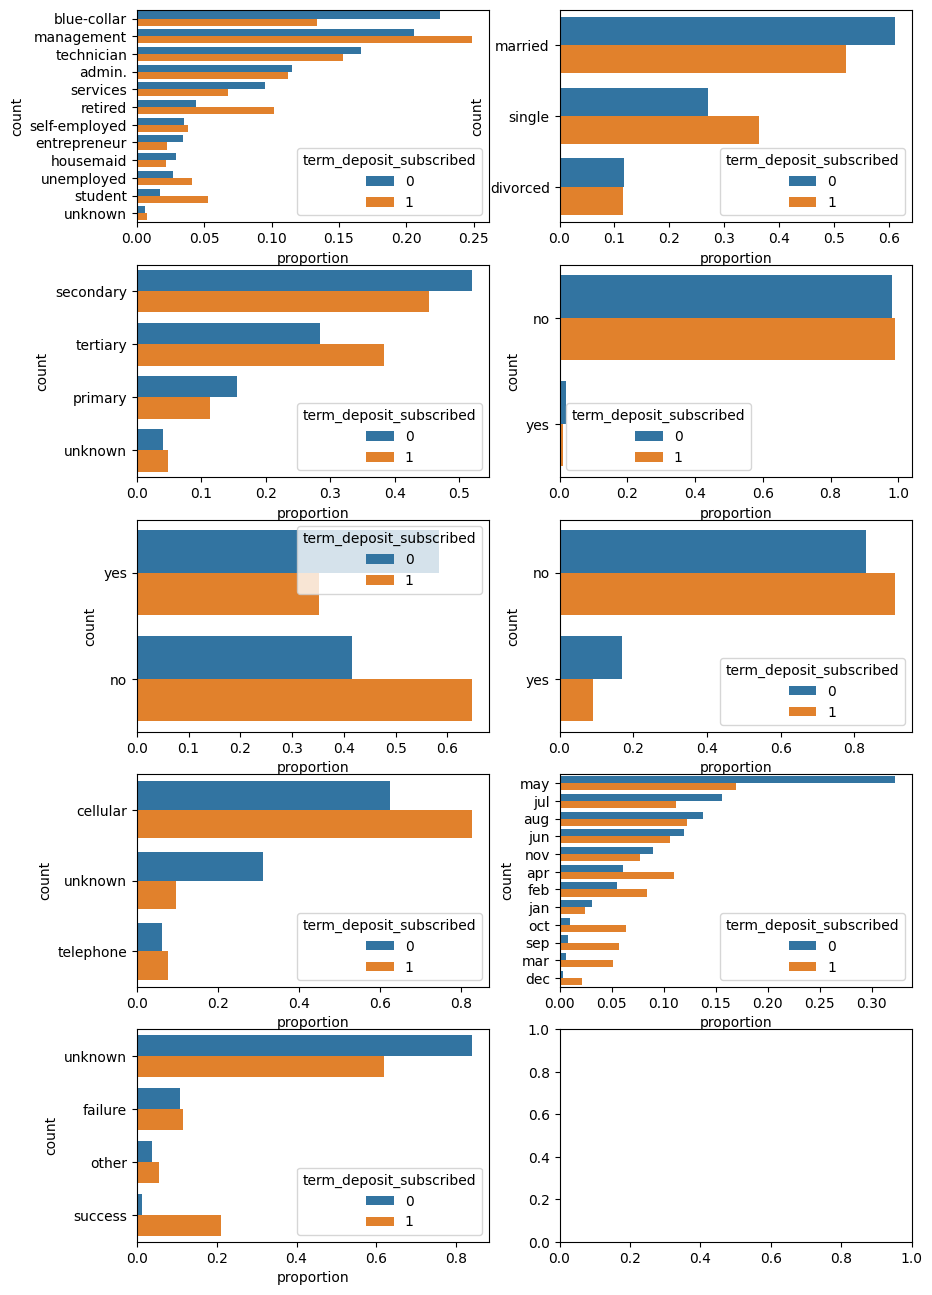

In [11]:
fig, axes = plt.subplots(5, 2, figsize=(10,16))

axes = [ax for axes_rows in axes for ax in axes_rows]

target_col = 'term_deposit_subscribed'

for i, column in enumerate(df[cat_cols]):
    fltr = df[target_col]== 0

    vc_a=df[fltr][column].value_counts(normalize=True).reset_index().rename({'index':column,column:'count'}, axis=1)

    vc_b=df[~fltr][column].value_counts(normalize=True).reset_index().rename({'index':column,column:'count'}, axis=1)

    vc_a[target_col]=0
    vc_b[target_col]=1

    print(vc_a)
    #print(vc_b)

    result = pd.DataFrame()
    result = pd.concat([result, vc_a, vc_b]).reset_index(drop=True)

    sns.barplot(y='count', x='proportion', data=result, hue=target_col, ax=axes[i])

In [12]:
features = [c for c in df.columns if c not in ['id', 'term_deposit_subscribed']]
num_cols = [c for c in features if c not in cat_cols]
num_cols

['customer_age',
 'balance',
 'day_of_month',
 'last_contact_duration',
 'num_contacts_in_campaign',
 'days_since_prev_campaign_contact',
 'num_contacts_prev_campaign']

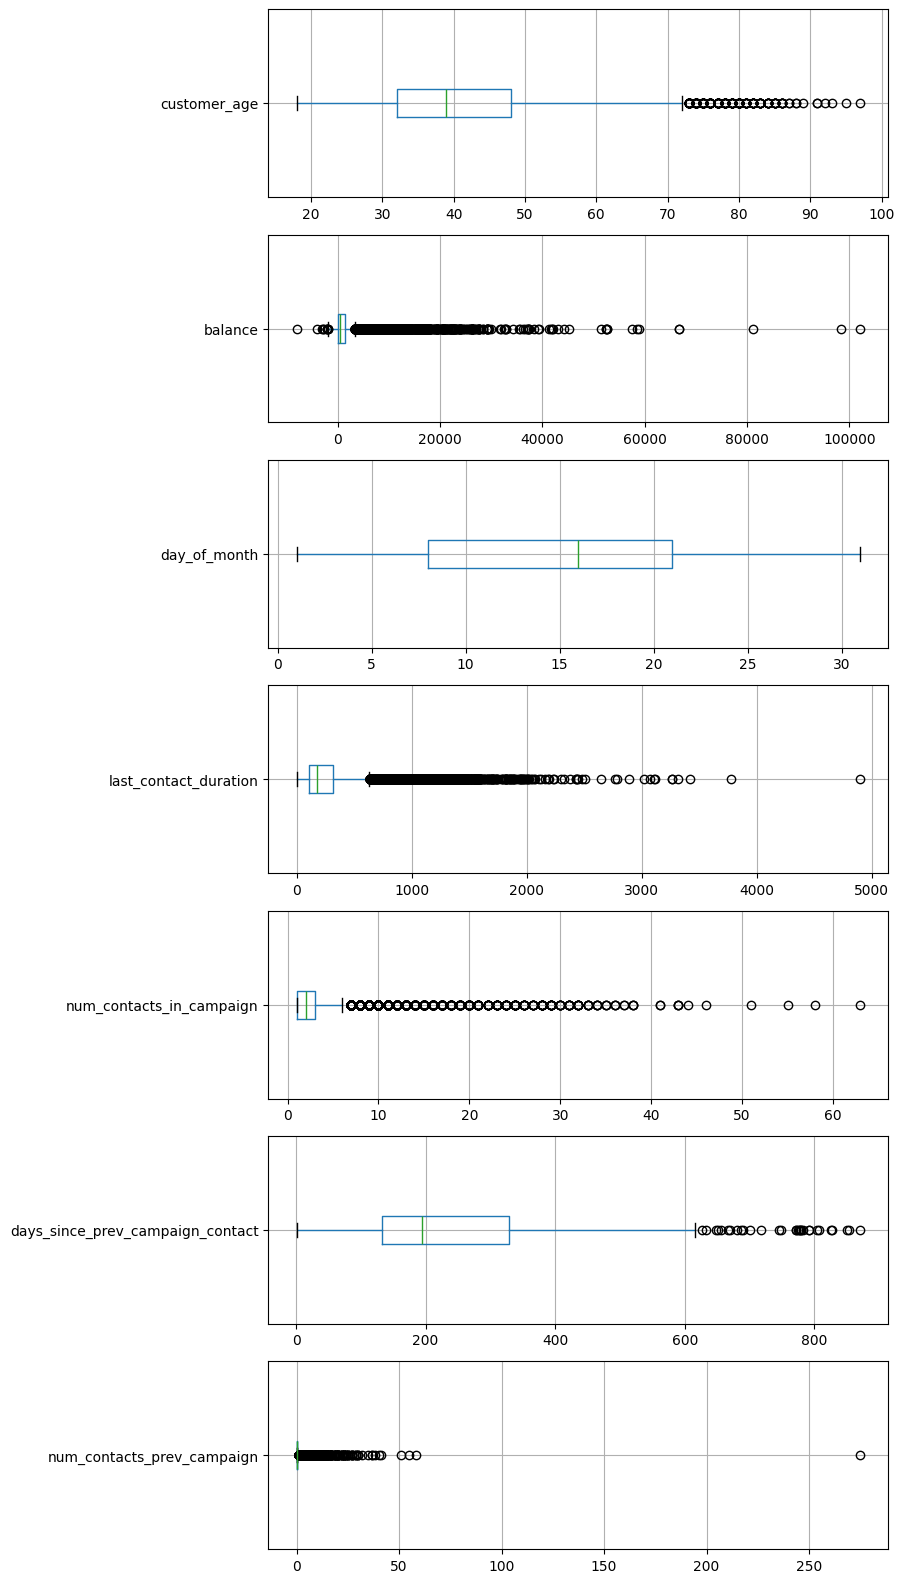

In [13]:
fig, axes = plt.subplots(7, 1, figsize=(8,20))
for i, c in enumerate(df[num_cols]):
    df[[c]].boxplot(ax=axes[i], vert=False)

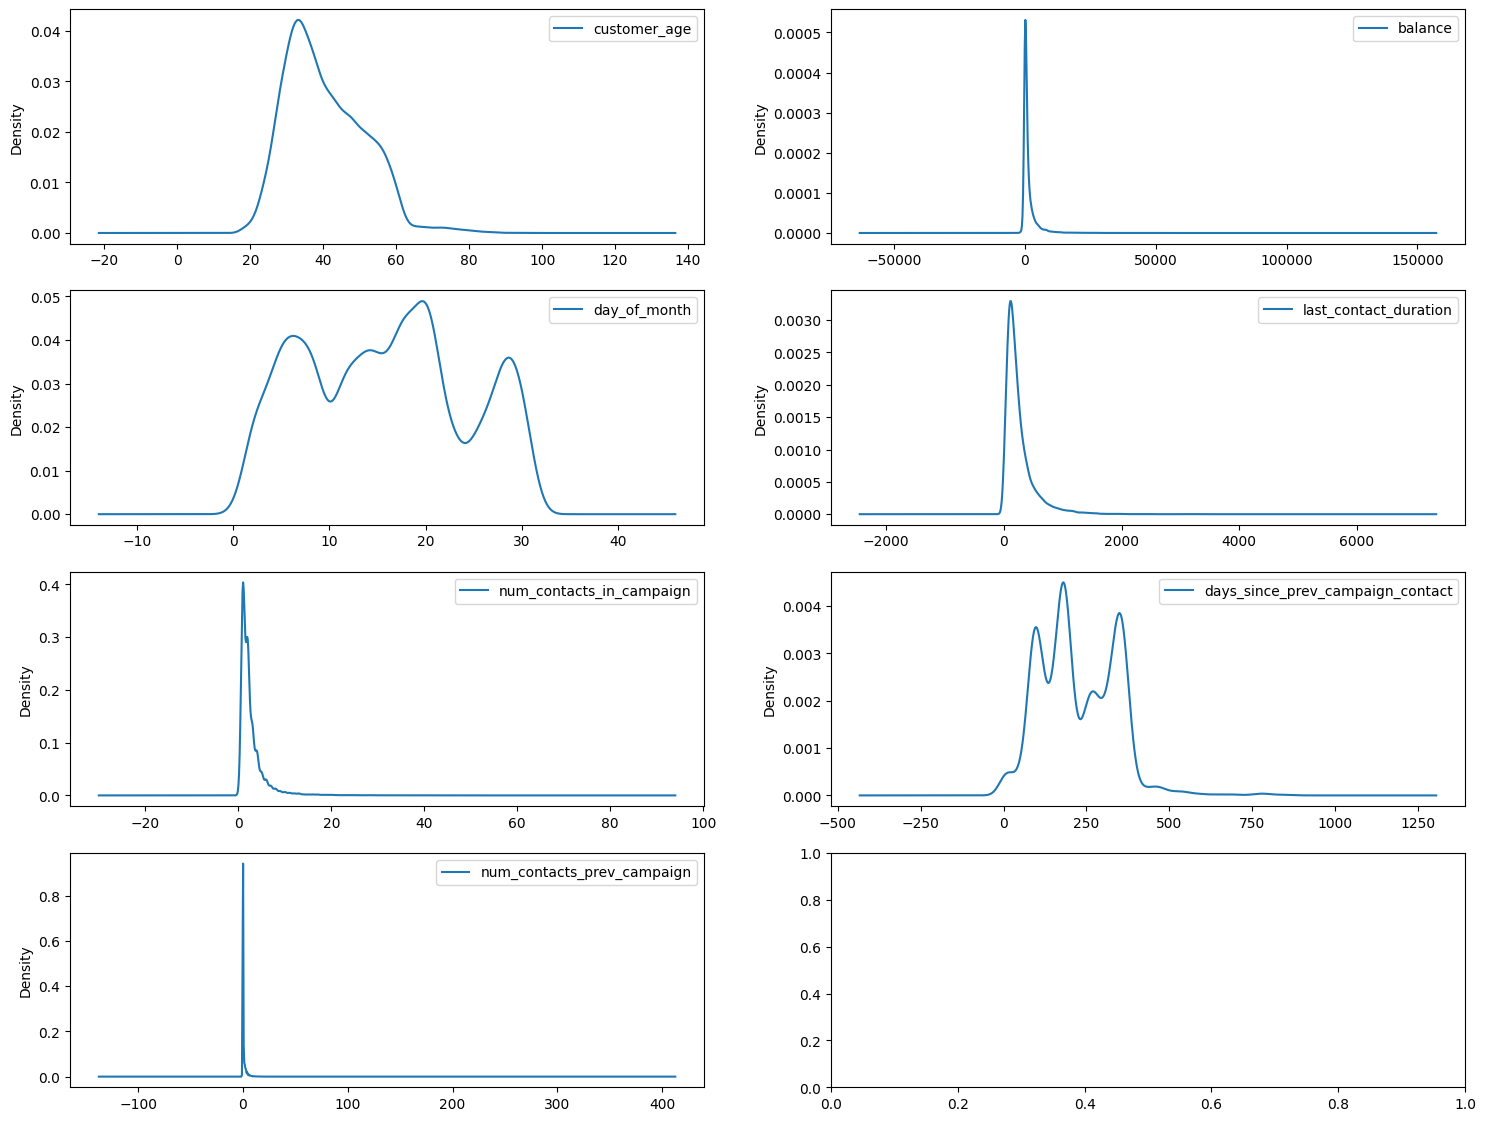

In [14]:
fig, axes = plt.subplots(4, 2, figsize=(18,14))
axes = [ax for axes_rows in axes for ax in axes_rows]

for i, c in enumerate(num_cols):
    plot = df[[c]].plot(kind='kde', ax=axes[i])

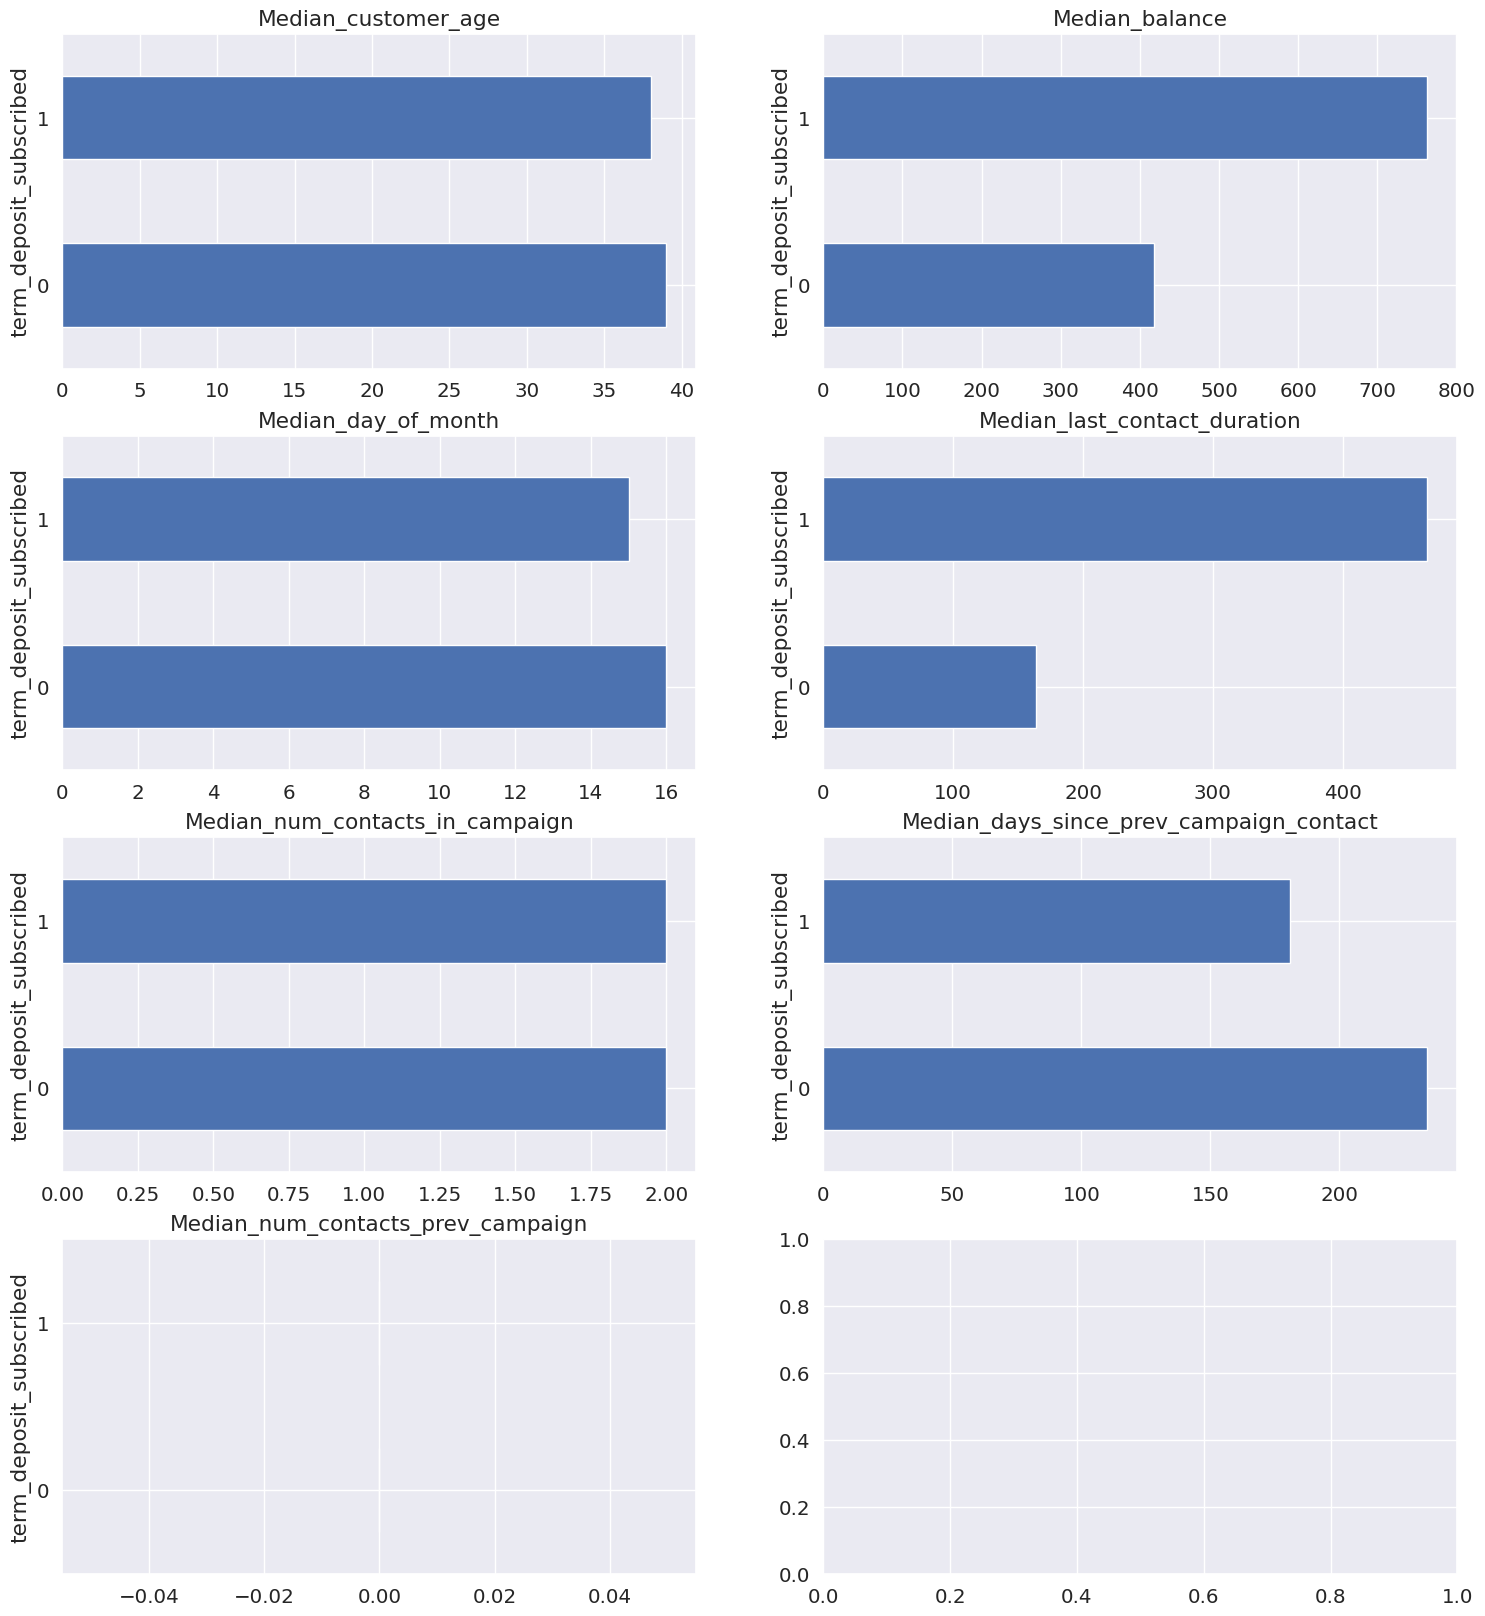

In [15]:
sns.set(font_scale = 1.3)

fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = [ax for axes_row in axes for ax in axes_row]

for i, c in enumerate(num_cols):
    df.groupby(target_col)[c].median().plot(kind = 'barh', title=f'Median_{c}', ax=axes[i])

<Axes: title={'center': 'Probability of subscribing to a term deposit'}, ylabel='is_old'>

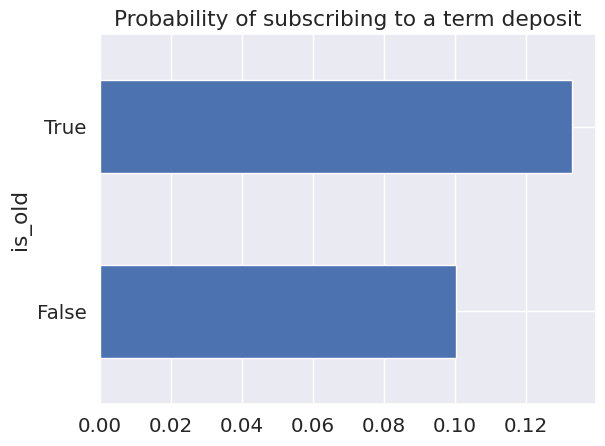

In [17]:
df['is_old'] = True

df.loc[df['customer_age'] <= 50, 'is_old'] = False

df.groupby('is_old')[target_col].mean().sort_values().plot(kind = 'barh', title='Probability of subscribing to a term deposit')